# Lecture 4 — makemore Part 3: Activations, Gradients & BatchNorm

**Karpathy Zero to Hero — Lecture 4**  
Video: https://www.youtube.com/watch?v=P6sfmUTpUmc

## What we're building
Start from the L3 MLP. Diagnose and fix the problems that appear when you scale it up:
1. **Saturated tanh activations** — why random init breaks gradients
2. **Fixing initial loss** — logit layer should start near uniform
3. **Kaiming init** — correct weight scaling for hidden layers
4. **Batch Normalization** — normalize pre-activations across the batch
5. **Running stats** — how BatchNorm works at inference time
6. **PyTorch-style module rewrite** — clean OOP implementation

## Roadmap
1. Rebuild L3 MLP (baseline)
2. Diagnose activation/gradient problems
3. Fix with proper initialization
4. Add BatchNorm layer from scratch
5. Verify with running mean/variance
6. Rewrite as PyTorch-style modules
7. Sample from the model

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

## 1. Load dataset + build vocabulary

In [3]:
words = open('names.txt', 'r').read().splitlines()
print(len(words), words[:8])

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(f'vocab size: {vocab_size}')

32033 ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
vocab size: 27


## 2. Build dataset (same as L3)

In [4]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr   = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte   = build_dataset(words[n2:])
print(Xtr.shape, Ytr.shape)

torch.Size([182625, 3]) torch.Size([182625])


## 3. Baseline MLP (from L3)

Rebuild the L3 MLP exactly. We'll then diagnose what's wrong with it.

In [5]:
# Hyperparameters
n_embd   = 10   # embedding size (upgraded from L3's 2)
n_hidden = 200  # hidden layer size
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd),                    generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden),         generator=g)
b1 = torch.randn(n_hidden,                                generator=g)
W2 = torch.randn((n_hidden, vocab_size),                  generator=g)
b2 = torch.randn(vocab_size,                              generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters), 'parameters')
for p in parameters:
    p.requires_grad = True

11897 parameters


## 4. Diagnose the problems

Before training, let's look at what's wrong with the default initialization.

### Problem 1: Initial loss is way too high
With 27 possible characters, a uniform distribution gives loss = `-log(1/27) ≈ 3.29`.  
Our random init gives much higher loss — because the logits are all over the place.

In [6]:
# Forward pass on one batch — check initial loss
ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

emb    = C[Xb]                              # (32, block_size, n_embd)
embcat = emb.view(emb.shape[0], -1)         # (32, block_size * n_embd)
hpreact = embcat @ W1 + b1                  # pre-activation
h       = torch.tanh(hpreact)               # hidden layer
logits  = h @ W2 + b2
loss    = F.cross_entropy(logits, Yb)

print(f'Initial loss:    {loss.item():.4f}')
print(f'Expected (uniform): {-torch.log(torch.tensor(1/27)):.4f}')

Initial loss:    27.8817
Expected (uniform): 3.2958


### Problem 2: Saturated tanh activations

Plot the distribution of `h` (post-tanh). You'll see most values are near -1 or +1.  
This means gradients are near zero — the network can't learn.

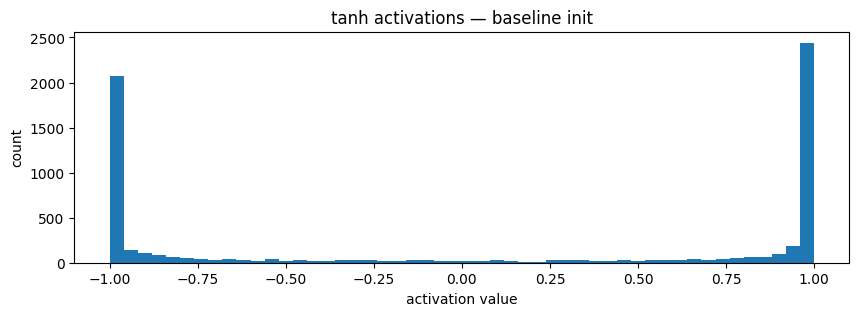

Fraction saturated: 60.95%


In [7]:
# Plot histogram of tanh activations
plt.figure(figsize=(10, 3))
plt.hist(h.view(-1).detach().numpy(), bins=50)
plt.title('tanh activations — baseline init')
plt.xlabel('activation value')
plt.ylabel('count')
plt.show()

# What fraction are saturated (|h| > 0.99)?
saturated = (h.abs() > 0.99).float().mean()
print(f'Fraction saturated: {saturated.item():.2%}')

## 5. Fix 1 — Kaiming initialization

The fix: scale W1 by `gain / sqrt(fan_in)`.  
For tanh, gain = 5/3. fan_in = number of input features to the layer.

WHY: without this, the pre-activations `embcat @ W1` have std >> 1,  
which pushes tanh into its flat saturated regions.

In [8]:
# YOUR CODE HERE — reinitialize W1 with Kaiming scaling
# W1 = torch.randn(...) * ???
# Also fix W2 and b2 so initial logits are near zero (uniform distribution)
# W2 = torch.randn(...) * 0.01
# b2 = torch.zeros(vocab_size)

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((block_size * n_embd, n_hidden),  generator=g) * (5/3) / ((block_size * n_embd)**0.5)  # Kaiming
b1 = torch.randn(n_hidden,                         generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),           generator=g) * 0.01  # near-zero init → uniform logits
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

# Re-run forward pass and check loss + saturation
emb     = C[Xb]
embcat  = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h       = torch.tanh(hpreact)
logits  = h @ W2 + b2
loss    = F.cross_entropy(logits, Yb)

print(f'Loss after Kaiming init: {loss.item():.4f}  (should be ~3.29)')
saturated = (h.abs() > 0.99).float().mean()
print(f'Fraction saturated:      {saturated.item():.2%}  (should be much lower)')

Loss after Kaiming init: 3.3180  (should be ~3.29)
Fraction saturated:      8.53%  (should be much lower)


## 6. Batch Normalization — from scratch

BatchNorm normalizes the pre-activations (`hpreact`) across the batch so they have mean=0, std=1.  
Then it applies learnable scale `bngain` (gamma) and shift `bnbias` (beta).

### Why it works
- Forces pre-activations into the linear region of tanh at the start of training
- Makes the network less sensitive to weight initialization
- Acts as a regularizer (batch statistics add noise during training)

### Two modes
- **Training**: normalize using the current batch's mean and std
- **Inference**: use running mean/std accumulated during training (no batch available)

In [9]:
# BatchNorm parameters — learnable scale and shift
bngain = torch.ones((1, n_hidden))   # gamma — initialized to 1
bnbias = torch.zeros((1, n_hidden))  # beta  — initialized to 0

# Running stats — updated during training, used at inference
bn_mean_running = torch.zeros((1, n_hidden))
bn_std_running  = torch.ones((1, n_hidden))

# Add to parameters list
parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters), 'parameters')

12297 parameters


In [10]:
def batchnorm_forward(hpreact, bngain, bnbias, bn_mean_running, bn_std_running, training=True):
    if training:
        batch_mean = hpreact.mean(0, keepdim=True)
        batch_std = hpreact.std(0, keepdim=True)
        with torch.no_grad():
            bn_mean_running = 0.999 * bn_mean_running + 0.001 * batch_mean
            bn_std_running = 0.999 * bn_std_running + 0.001 * batch_std

    else:
        # use running stats
        batch_mean = bn_mean_running
        batch_std = bn_std_running
    
    # normalize
    hpreact_norm = (hpreact - batch_mean) / (batch_std + 1e-5)

    # scale and shift
    hpreact_bn = bngain * hpreact_norm + bnbias
    
    return hpreact_bn, batch_mean, batch_std


# BatchNorm forward pass (training mode)
# YOUR CODE HERE — implement this from scratch

# Step 1: compute batch mean and std of hpreact
# bnmean_i  = hpreact.mean(0, keepdim=True)          # mean across batch dim
# bnstd_i   = hpreact.std(0, keepdim=True)           # std across batch dim

# Step 2: normalize
# hpreact_norm = (hpreact - bnmean_i) / (bnstd_i + 1e-5)

# Step 3: scale and shift with learnable params
# hpreact_bn = bngain * hpreact_norm + bnbias

# Step 4: update running stats (no grad needed)
# with torch.no_grad():
#     bn_mean_running = 0.999 * bn_mean_running + 0.001 * bnmean_i
#     bn_std_running  = 0.999 * bn_std_running  + 0.001 * bnstd_i

# Then: h = torch.tanh(hpreact_bn)

# YOUR CODE — fill it all in below:
bnmean_i      = hpreact.mean(0, keepdim=True)
bnstd_i       = hpreact.std(0, keepdim=True)
hpreact_norm  = (hpreact - bnmean_i) / (bnstd_i + 1e-5)
hpreact_bn    = bngain * hpreact_norm + bnbias
h             = torch.tanh(hpreact_bn)

# Verify: mean should be ~0, std ~1
print(f'hpreact_bn mean: {hpreact_bn.mean().item():.4f}  (expect ~0)')
print(f'hpreact_bn std:  {hpreact_bn.std().item():.4f}  (expect ~1)')

saturated = (h.abs() > 0.99).float().mean()
print(f'Fraction saturated: {saturated.item():.2%}  (should be near 0)')

hpreact_bn mean: 0.0000  (expect ~0)
hpreact_bn std:  0.9843  (expect ~1)
Fraction saturated: 0.55%  (should be near 0)


## 7. Full training loop with BatchNorm

In [11]:
# Re-initialize everything cleanly
g = torch.Generator().manual_seed(2147483647)

C      = torch.randn((vocab_size, n_embd),             generator=g)
W1     = torch.randn((block_size * n_embd, n_hidden),  generator=g) * (5/3) / ((block_size * n_embd)**0.5)
b1     = torch.randn(n_hidden,                         generator=g) * 0.1
# WHY: b1 is technically redundant when using BatchNorm (BN subtracts the mean)
# Karpathy sets it anyway — we'll see he removes it in the clean version
W2     = torch.randn((n_hidden, vocab_size),           generator=g) * 0.01
b2     = torch.zeros(vocab_size)
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

bn_mean_running = torch.zeros((1, n_hidden))
bn_std_running  = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters), 'parameters')

12297 parameters


      0/ 200000: 3.2955
  10000/ 200000: 2.3899
  20000/ 200000: 1.9544
  30000/ 200000: 2.4590
  40000/ 200000: 2.4383
  50000/ 200000: 1.7689
  60000/ 200000: 2.1728
  70000/ 200000: 1.8646
  80000/ 200000: 2.2903
  90000/ 200000: 2.2932
 100000/ 200000: 2.2417
 110000/ 200000: 2.0247
 120000/ 200000: 2.0188
 130000/ 200000: 2.2637
 140000/ 200000: 1.7828
 150000/ 200000: 2.3077
 160000/ 200000: 2.0755
 170000/ 200000: 1.8959
 180000/ 200000: 1.7238
 190000/ 200000: 2.1634


Text(0.5, 1.0, 'Training loss curve')

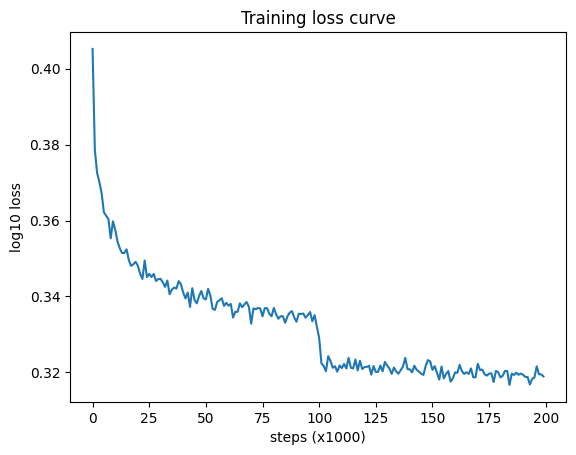

In [12]:
max_steps  = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch
    ix  = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb     = C[Xb]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    # BatchNorm — training mode
    bnmean_i     = hpreact.mean(0, keepdim=True)
    bnstd_i      = hpreact.std(0, keepdim=True)
    hpreact_norm = (hpreact - bnmean_i) / (bnstd_i + 1e-5)
    hpreact_bn   = bngain * hpreact_norm + bnbias

    # Update running stats (no grad)
    with torch.no_grad():
        bn_mean_running = 0.999 * bn_mean_running + 0.001 * bnmean_i
        bn_std_running  = 0.999 * bn_std_running  + 0.001 * bnstd_i

    h      = torch.tanh(hpreact_bn)
    logits = h @ W2 + b2
    loss   = F.cross_entropy(logits, Yb)

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
plt.xlabel('steps (x1000)')
plt.ylabel('log10 loss')
plt.title('Training loss curve')

## 8. Evaluate — train/dev split

In [13]:
@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'dev': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb     = C[x]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    # Inference mode — use running stats, NOT batch stats
    # WHY: at inference there's no batch to compute mean/std from
    hpreact_norm = (hpreact - bn_mean_running) / (bn_std_running + 1e-5)
    hpreact_bn   = bngain * hpreact_norm + bnbias

    h      = torch.tanh(hpreact_bn)
    logits = h @ W2 + b2
    loss   = F.cross_entropy(logits, y)
    print(f'{split:5s} loss: {loss.item():.4f}')

split_loss('train')
split_loss('dev')

train loss: 2.0670
dev   loss: 2.1065


## 9. Dead-reckon exercise — BatchNorm from memory

Close the lecture. Implement BatchNorm forward pass from scratch in the cell below  
without looking at the cells above. Just the math:
1. Compute batch mean and std
2. Normalize
3. Scale + shift with gamma and beta
4. Update running stats

In [15]:
class Linear:
    def __init__(self, n_in, n_out, bias=True):
        self.weight = torch.randn((n_out, n_in)) * (5/3) / ((n_in)**0.5)
        self.bias = torch.zeros(n_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight.T
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
class BatchNorm:
    def __init__(self, n_in, eps=1e-5):
        self.gamma = torch.ones((1, n_in))
        self.beta = torch.zeros((1, n_in))
        self.mean_running = torch.zeros((1, n_in))
        self.std_running = torch.ones((1, n_in))
        self.eps = eps
        self.training = True

    def __call__(self, x, training=True):
        if self.training:
            self.mean = x.mean(0, keepdim=True)
            self.std = x.std(0, keepdim=True)
        else:
            self.mean = self.mean_running
            self.std = self.std_running
        
        x_norm = (x - self.mean) / (self.std + self.eps)
        out = self.gamma * x_norm + self.beta
        
        if self.training:
            with torch.no_grad():
                self.mean_running = 0.999 * self.mean_running + 0.001 * self.mean
                self.std_running = 0.999 * self.std_running + 0.001 * self.std
        
        return out
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

## 10. Sample from the model

In [16]:
g2 = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb     = C[torch.tensor([context])]
        embcat  = emb.view(1, -1)
        hpreact = embcat @ W1 + b1

        # Inference: use running stats
        hpreact_norm = (hpreact - bn_mean_running) / (bn_std_running + 1e-5)
        hpreact_bn   = bngain * hpreact_norm + bnbias
        h      = torch.tanh(hpreact_bn)
        logits = h @ W2 + b2
        probs  = F.softmax(logits, dim=1)
        ix     = torch.multinomial(probs, num_samples=1, generator=g2).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out[:-1]))

carmahzari
harli
jari
reity
salaysie
mahnee
delynn
jareei
ner
kiah
maiir
kaleigh
ham
jocn
quinthoron
marianni
waythoniearyn
kai
evellsabee
deci
